<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/30_march_Regression_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Science Master

In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, pickle, joblib, time
warnings.filterwarnings('ignore')

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import (
    ElasticNet, ElasticNetCV, Lasso, LassoCV, Ridge, RidgeCV, LinearRegression
)
from sklearn.preprocessing  import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets        import make_regression, fetch_california_housing
from sklearn.pipeline        import Pipeline
from sklearn.impute          import SimpleImputer, KNNImputer

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F0F4F8',
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})

C1,C2,C3,C4,C5,C6 = '#E63946','#1D3557','#457B9D','#2EC4B6','#FF9F1C','#6A0572'

print('✅  All libraries imported.')
print(f'    NumPy {np.__version__} | Pandas {pd.__version__}')


✅  All libraries imported.
    NumPy 2.0.2 | Pandas 2.2.2


---
## Q1 — What is Elastic Net Regression and how does it differ from other regression techniques?


### 📖 Theory

**Elastic Net Regression** is a regularised linear model that combines the **L1 penalty** (Lasso)
and the **L2 penalty** (Ridge) into a single objective:

$$\text{Elastic Net} = \underbrace{\|y - X\beta\|^2}_{\text{RSS}} \ + \ \lambda_1\underbrace{\sum_{j=1}^p|\beta_j|}_{\text{L1 (Lasso)}} \ + \ \lambda_2\underbrace{\sum_{j=1}^p\beta_j^2}_{\text{L2 (Ridge)}}$$

In `sklearn` this is re-parameterised as:
$$\text{Elastic Net} = \text{RSS} \ + \ \alpha\Big[\rho\cdot\|\beta\|_1 \ + \ \frac{1-\rho}{2}\cdot\|\beta\|_2^2\Big]$$

where **α** = overall regularisation strength, **ρ (l1_ratio)** = mix between L1 and L2.

#### Comparison with other techniques

| Property | OLS | Ridge (L2) | Lasso (L1) | **Elastic Net** |
|----------|-----|-----------|-----------|----------------|
| Penalty | None | $\lambda\sum\beta_j^2$ | $\lambda\sum|\beta_j|$ | L1 + L2 |
| Coefficients → 0? | ❌ | ❌ | ✅ | ✅ |
| Feature selection | ❌ | ❌ | ✅ | ✅ |
| Handles multicollinearity | ❌ | ✅ | ⚠️ Unstable | ✅ Stable |
| Groups correlated features | ❌ | ✅ | ❌ | ✅ Grouping effect |
| Works when p ≫ n | ❌ | ✅ | ✅ | ✅ |
| No. of tuning params | 0 | 1 (λ) | 1 (λ) | **2 (α, ρ)** |


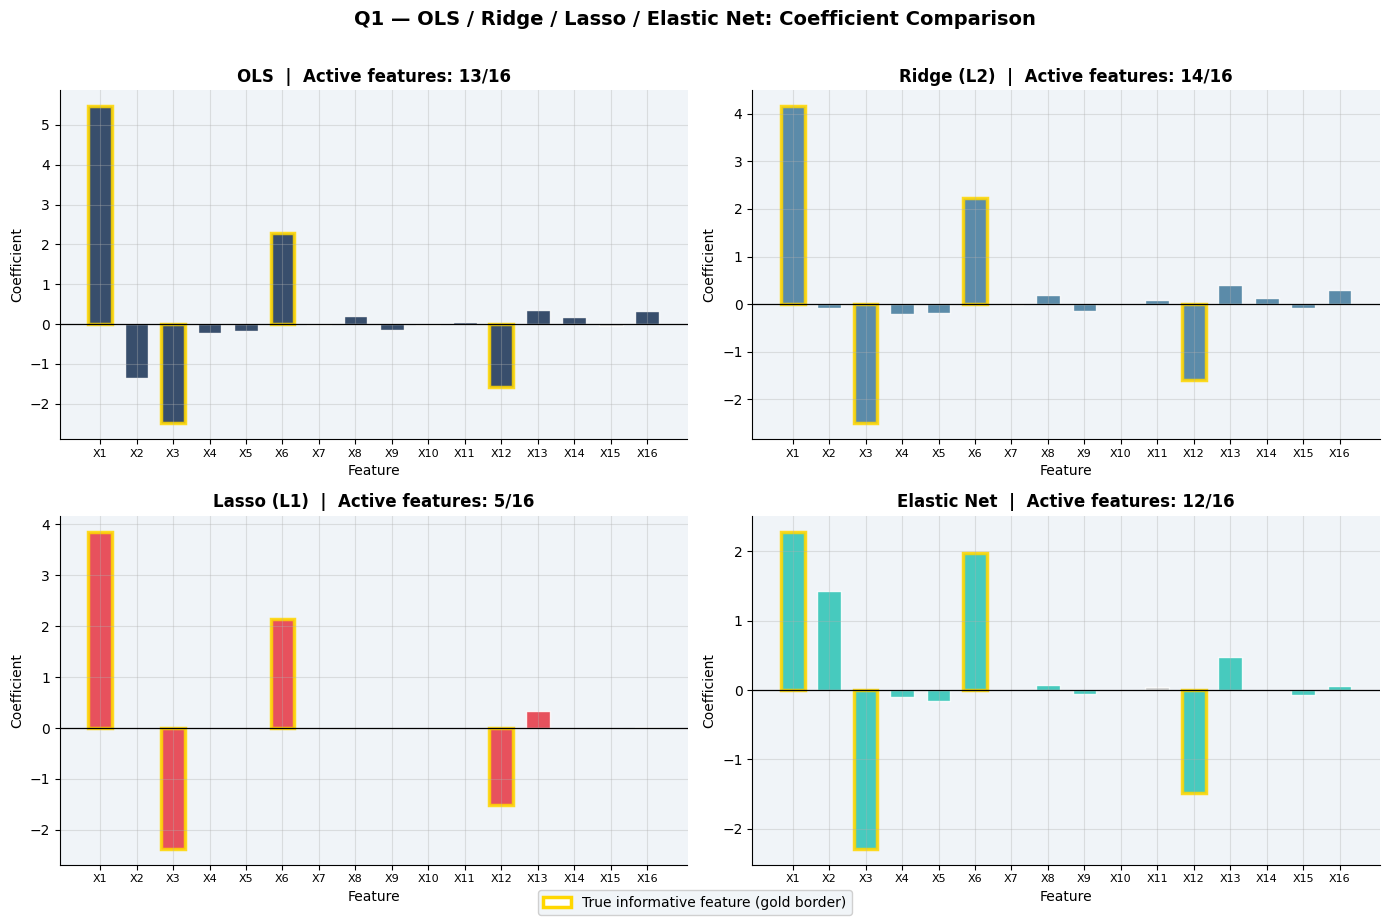

Note: X1 & X2 are highly correlated (ρ≈0.99).
Ridge & Elastic Net share weight; Lasso arbitrarily picks one.


In [2]:
# ── Q1: Visual comparison of all four methods ────────────────────────────────
np.random.seed(42)
n, p = 120, 16

# 4 informative, 12 noise features
true_coef = np.zeros(p)
true_coef[[0, 2, 5, 11]] = [4.5, -3.0, 2.5, -1.8]

X = np.random.randn(n, p)
# Add multicollinearity: feature 1 ≈ feature 0
X[:, 1] = X[:, 0] + np.random.randn(n) * 0.15
y = X @ true_coef + np.random.randn(n) * 2.0

sc = StandardScaler()
Xs = sc.fit_transform(X)

models_q1 = {
    'OLS'         : LinearRegression(),
    'Ridge (L2)'  : Ridge(alpha=1.0),
    'Lasso (L1)'  : Lasso(alpha=0.2, max_iter=10000),
    'Elastic Net' : ElasticNet(alpha=0.2, l1_ratio=0.5, max_iter=10000),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors_q1 = [C2, C3, C1, C4]
feat_labels = [f'X{i+1}' for i in range(p)]

for ax, (name, mdl), col in zip(axes, models_q1.items(), colors_q1):
    mdl.fit(Xs, y)
    coefs = mdl.coef_
    bar_cols = [col if abs(c) > 0.05 else '#CCCCCC' for c in coefs]
    bars = ax.bar(feat_labels, coefs, color=bar_cols, alpha=0.87, edgecolor='white', width=0.65)
    # Gold border on true features
    for idx in [0, 2, 5, 11]:
        bars[idx].set_edgecolor('#FFD700')
        bars[idx].set_linewidth(2.5)
    ax.axhline(0, color='black', lw=0.9)
    nz = np.sum(np.abs(coefs) > 0.05)
    ax.set_title(f'{name}  |  Active features: {nz}/{p}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Coefficient'); ax.set_xlabel('Feature')
    ax.tick_params(axis='x', labelsize=8)

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(facecolor='white', edgecolor='gold', lw=2.5,
                   label='True informative feature (gold border)')],
    loc='lower center', fontsize=10, framealpha=0.9
)
plt.suptitle('Q1 — OLS / Ridge / Lasso / Elastic Net: Coefficient Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Note: X1 & X2 are highly correlated (ρ≈0.99).')
print('Ridge & Elastic Net share weight; Lasso arbitrarily picks one.')


---
## Q2 — How do you choose the optimal values of the regularisation parameters?


### 📖 Theory

Elastic Net has **two hyperparameters**:

| Parameter | Symbol | Range | Effect |
|-----------|--------|-------|--------|
| Overall regularisation | α (alpha) | (0, ∞) | Higher → more shrinkage → sparser + smoother |
| L1 vs L2 mix | ρ (l1_ratio) | [0, 1] | 0 = pure Ridge, 1 = pure Lasso |

#### Selection strategies

| Method | Tool | Notes |
|--------|------|-------|
| **ElasticNetCV** | `sklearn.linear_model.ElasticNetCV` | Efficient built-in CV over α & ρ grid |
| **GridSearchCV** | `sklearn.model_selection.GridSearchCV` | Full cross-validated grid search |
| **Manual k-Fold** | Custom loop | Maximum control |

#### Recommended grid
```python
alphas    = np.logspace(-4, 2, 100)          # log-spaced
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]
model     = ElasticNetCV(l1_ratio=l1_ratios, alphas=alphas, cv=5)
```


In [11]:
# ElasticNetCV mse_path
mean_mse = np.sqrt(encv.mse_path_.mean(axis=-1))

best_rho_idx = list(l1_ratios2).index(encv.l1_ratio_)

for i, rho in enumerate(l1_ratios2):

    lw = 2.8 if i == best_rho_idx else 1.2
    al = 1.0 if i == best_rho_idx else 0.45

    axes[1].semilogx(
        encv.alphas_,
        mean_mse[i],
        lw=lw,
        alpha=al,
        label=f'ρ={rho}' + (' ← best' if i == best_rho_idx else '')
    )

axes[1].axvline(
    encv.alpha_,
    color='black',
    ls=':',
    lw=2,
    label=f'Optimal α={encv.alpha_:.4f}'
)

axes[1].set_xlabel('α (log scale)', fontsize=11)
axes[1].set_ylabel('CV RMSE')
axes[1].set_title('ElasticNetCV Path per l1_ratio',
                  fontsize=12,
                  fontweight='bold')

axes[1].legend(fontsize=8, ncol=2)

---
## Q3 — What are the advantages and disadvantages of Elastic Net Regression?


### 📖 Advantages

| ✅ Advantage | Explanation |
|-------------|-------------|
| **Combines L1 + L2** | Gets sparsity from Lasso AND stability from Ridge |
| **Grouping effect** | Selects or drops *groups* of correlated features together |
| **Works when p ≫ n** | Handles high-dimensional genomics, NLP, finance data |
| **Handles multicollinearity** | More stable than pure Lasso when features are correlated |
| **Flexible** | Reduces to Ridge (ρ=0) or Lasso (ρ=1) as special cases |
| **Automatic feature selection** | Sets some coefficients to exactly zero |

### 📖 Disadvantages

| ❌ Disadvantage | Explanation |
|----------------|-------------|
| **Two hyperparameters** | α and ρ both need tuning → larger search space |
| **Biased coefficients** | Shrinkage introduces bias — not suitable for causal inference |
| **Feature scaling required** | Sensitive to unscaled features |
| **Still linear** | Cannot capture non-linear relationships without feature engineering |
| **Computational cost** | CV over 2D grid is more expensive than Ridge/Lasso |
| **Less interpretable than OLS** | Penalised coefficients are not true partial effects |


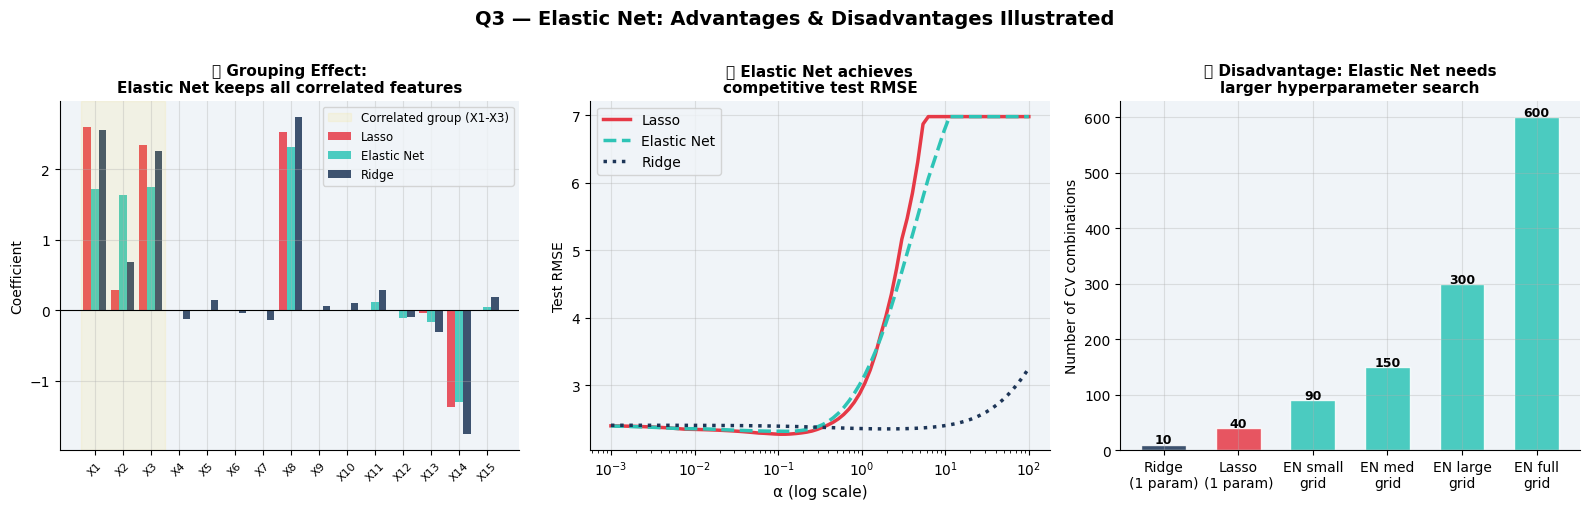

In [4]:
# ── Q3: Pros & cons illustrated — bias-variance & grouping effect ─────────────
np.random.seed(42)
n3, p3 = 150, 15

# Grouping effect demo: 3 highly correlated features (X0,X1,X2)
X3_base = np.random.randn(n3, p3)
X3_base[:, 1] = X3_base[:, 0] + np.random.randn(n3)*0.1
X3_base[:, 2] = X3_base[:, 0] + np.random.randn(n3)*0.1
true3 = np.zeros(p3); true3[[0,1,2,7,13]] = [2,2,2,3,-1.5]
y3 = X3_base @ true3 + np.random.randn(n3)*2
sc3 = StandardScaler(); X3s = sc3.fit_transform(X3_base)

lasso3 = Lasso(alpha=0.3, max_iter=10000).fit(X3s, y3)
enet3  = ElasticNet(alpha=0.3, l1_ratio=0.5, max_iter=10000).fit(X3s, y3)
ridge3 = Ridge(alpha=1.0).fit(X3s, y3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grouping effect
feat3 = [f'X{i+1}' for i in range(p3)]
x3 = np.arange(p3); w3 = 0.28
axes[0].bar(x3-w3, lasso3.coef_, w3, color=C1, alpha=0.85, label='Lasso')
axes[0].bar(x3,    enet3.coef_,  w3, color=C4, alpha=0.85, label='Elastic Net')
axes[0].bar(x3+w3, ridge3.coef_, w3, color=C2, alpha=0.85, label='Ridge')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvspan(-0.5, 2.5, alpha=0.08, color='gold', label='Correlated group (X1-X3)')
axes[0].set_xticks(x3); axes[0].set_xticklabels(feat3, rotation=45, fontsize=8)
axes[0].set_title('✅ Grouping Effect:\nElastic Net keeps all correlated features',
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel('Coefficient'); axes[0].legend(fontsize=8.5)

# Bias-variance tradeoff comparison
lambdas3 = np.logspace(-3, 2, 80)
X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3s, y3, test_size=0.25, random_state=0)

for name, maker, col, ls in [
    ('Lasso',       lambda a: Lasso(alpha=a, max_iter=10000),                  C1, '-'),
    ('Elastic Net', lambda a: ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000), C4, '--'),
    ('Ridge',       lambda a: Ridge(alpha=a),                                  C2, ':'),
]:
    te_rmse = [np.sqrt(mean_squared_error(y3_te, maker(a).fit(X3_tr,y3_tr).predict(X3_te)))
               for a in lambdas3]
    axes[1].semilogx(lambdas3, te_rmse, lw=2.5, color=col, ls=ls, label=name)
axes[1].set_xlabel('α (log scale)', fontsize=11)
axes[1].set_ylabel('Test RMSE')
axes[1].set_title('✅ Elastic Net achieves\ncompetitive test RMSE', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)

# Disadvantage: 2D tuning cost
n_combos = [len(np.logspace(-3,2,k)) * len([0.1,0.5,1.0][:j])
             for k,j in [(10,1),(20,2),(30,3),(50,3),(100,5),(200,7)]]
labels3 = ['Ridge\n(1 param)','Lasso\n(1 param)',
            'EN small\ngrid','EN med\ngrid','EN large\ngrid','EN full\ngrid']
bar_cols3 = [C2,C1,C4,C4,C4,C4]
bars3 = axes[2].bar(labels3, n_combos, color=bar_cols3, alpha=0.85,
                     edgecolor='white', width=0.6)
for bar, v in zip(bars3, n_combos):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+2, str(v),
                 ha='center', fontweight='bold', fontsize=9)
axes[2].set_title('❌ Disadvantage: Elastic Net needs\nlarger hyperparameter search',
                   fontsize=11, fontweight='bold')
axes[2].set_ylabel('Number of CV combinations')

plt.suptitle('Q3 — Elastic Net: Advantages & Disadvantages Illustrated',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q4 — What are some common use cases for Elastic Net Regression?


### 📖 Theory

Elastic Net excels in settings that involve **high dimensionality**, **multicollinearity**, or the need for **simultaneous feature selection and stable estimation**.

| Domain | Use Case | Why Elastic Net? |
|--------|----------|------------------|
| 🧬 **Genomics / Bioinformatics** | Predicting gene expression, GWAS | p ≫ n, correlated SNPs |
| 💹 **Finance** | Asset return prediction, risk modelling | Many correlated financial factors |
| 🏥 **Healthcare** | Disease prediction from clinical features | Sparse + stable model needed |
| 📝 **NLP / Text** | Sentiment, topic classification (sparse TF-IDF) | High-d, correlated tokens |
| 🏠 **Real estate** | House price prediction | Correlated location/size features |
| 🌡️ **Climate science** | Temperature/rainfall modelling | Correlated spatial predictors |
| 🏭 **Manufacturing** | Predictive quality control | High-d sensor data |


California Housing Dataset
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude     Price
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00  20640.00   20640.00  20640.00
mean       3.87     28.64      5.43       1.10     1425.48      3.07     35.63    -119.57      2.07
std        1.90     12.59      2.47       0.47     1132.46     10.39      2.14       2.00      1.15
min        0.50      1.00      0.85       0.33        3.00      0.69     32.54    -124.35      0.15
25%        2.56     18.00      4.44       1.01      787.00      2.43     33.93    -121.80      1.20
50%        3.53     29.00      5.23       1.05     1166.00      2.82     34.26    -118.49      1.80
75%        4.74     37.00      6.05       1.10     1725.00      3.28     37.71    -118.01      2.65
max       15.00     52.00    141.91      34.07    35682.00   1243.33     41.95    -114.31      5.00

Model Comparison on California Housing
               RMSE     MAE      

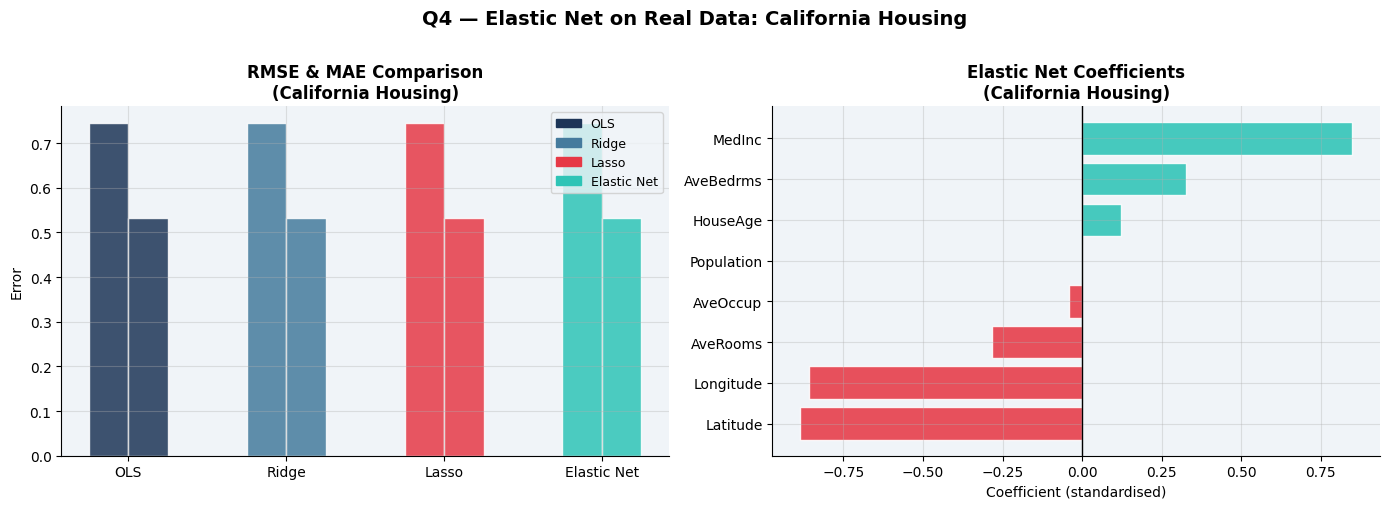

In [5]:
# ── Q4: Elastic Net on California Housing (real-world use case) ──────────────
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df4 = pd.DataFrame(housing.data, columns=housing.feature_names)
df4['Price'] = housing.target

print('California Housing Dataset')
print('='*50)
print(df4.describe().round(2).to_string())

X4 = df4.drop('Price', axis=1).values
y4 = df4['Price'].values

X4_tr, X4_te, y4_tr, y4_te = train_test_split(X4, y4, test_size=0.2, random_state=42)
sc4 = StandardScaler()
X4_tr_s = sc4.fit_transform(X4_tr)
X4_te_s = sc4.transform(X4_te)

# Fit and compare
models4 = {
    'OLS'        : LinearRegression(),
    'Ridge'      : RidgeCV(cv=5),
    'Lasso'      : LassoCV(cv=5, max_iter=20000),
    'Elastic Net': ElasticNetCV(l1_ratio=[0.3,0.5,0.7,0.9], cv=5, max_iter=20000),
}

results4 = {}
for name, mdl in models4.items():
    mdl.fit(X4_tr_s, y4_tr)
    yp = mdl.predict(X4_te_s)
    results4[name] = {
        'RMSE': np.sqrt(mean_squared_error(y4_te, yp)),
        'MAE' : mean_absolute_error(y4_te, yp),
        'R²'  : r2_score(y4_te, yp),
    }

print('\nModel Comparison on California Housing')
print('='*52)
print(pd.DataFrame(results4).T.round(4).to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results4.keys())
metrics4 = ['RMSE', 'MAE', 'R²']
x4 = np.arange(len(model_names)); w4 = 0.25
col4 = [C2, C3, C1, C4]
for i, (metric, offset) in enumerate(zip(['RMSE','MAE'], [-w4/2, w4/2])):
    vals = [results4[m][metric] for m in model_names]
    bars4 = axes[0].bar(x4+offset, vals, w4, color=col4, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x4); axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_title('RMSE & MAE Comparison\n(California Housing)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Error')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=c,label=n) for c,n in zip(col4,model_names)], fontsize=9)

# Elastic Net coefficients
en4 = models4['Elastic Net']
sorted_i4 = np.argsort(en4.coef_)
bar_c4 = [C1 if c<0 else C4 for c in en4.coef_[sorted_i4]]
axes[1].barh(np.array(housing.feature_names)[sorted_i4], en4.coef_[sorted_i4],
              color=bar_c4, alpha=0.88, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Elastic Net Coefficients\n(California Housing)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient (standardised)')

plt.suptitle('Q4 — Elastic Net on Real Data: California Housing',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q5 — How do you interpret the coefficients in Elastic Net Regression?


### 📖 Theory

Elastic Net coefficients are **biased and shrunken** but interpretable in relative terms.

#### Interpretation rules

| Rule | Detail |
|------|--------|
| **β = 0** | Feature excluded from model by regularisation |
| **β > 0** | 1 SD increase in Xⱼ → β increase in ŷ (after standardisation) |
| **β < 0** | 1 SD increase in Xⱼ → β decrease in ŷ |
| **\|β\| magnitude** | Larger = stronger association — *compare only after scaling* |
| **Not causal** | Regularisation biases estimates; do not interpret as causal effects |
| **l1_ratio effect** | Closer to 1 → more Lasso-like (sparser); closer to 0 → Ridge-like (smaller but non-zero) |

#### Effect of l1_ratio on coefficients
- **ρ = 1 (Lasso):** aggressive zeroing, sparse
- **ρ = 0 (Ridge):** all features retained, smooth shrinkage  
- **0 < ρ < 1 (Elastic Net):** balanced — groups of correlated features share weight


Optimal α=0.1221, ρ=0.90

Feature            Coefficient    Direction Relative Importance
--------------------------------------------------------------
MedInc                  0.6084   ↑ positive   ████████████████████
HouseAge               -0.0000   ◦ excluded   
AveRooms                0.0000   ◦ excluded   
AveBedrms              -0.0384   ◦ excluded   █
Population              0.0000   ◦ excluded   
AveOccup               -0.0702   ↓ negative   ██
Latitude                0.0382   ◦ excluded   █
Longitude               0.0275   ◦ excluded   


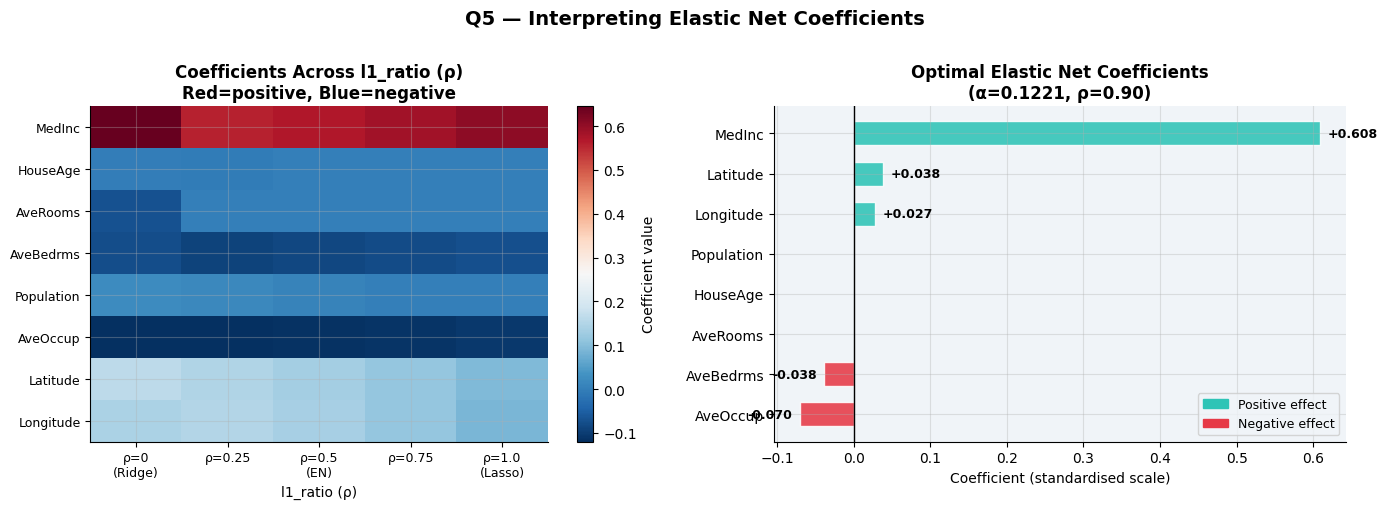

In [6]:
# ── Q5: Coefficient interpretation dashboard ─────────────────────────────────
np.random.seed(7)
n5 = 220

feat_names5 = ['MedInc','HouseAge','AveRooms','AveBedrms',
                'Population','AveOccup','Latitude','Longitude']
X5_raw = fetch_california_housing().data[:n5]
y5     = fetch_california_housing().target[:n5]

sc5 = StandardScaler()
X5s = sc5.fit_transform(X5_raw)

# Fit across l1_ratios
l1_ratios5 = [0.0, 0.25, 0.5, 0.75, 1.0]
labels5    = ['ρ=0\n(Ridge)', 'ρ=0.25', 'ρ=0.5\n(EN)', 'ρ=0.75', 'ρ=1.0\n(Lasso)']
coef_mat5  = []

for rho in l1_ratios5:
    if rho == 0.0:
        m = Ridge(alpha=0.5).fit(X5s, y5)
    elif rho == 1.0:
        m = Lasso(alpha=0.05, max_iter=10000).fit(X5s, y5)
    else:
        m = ElasticNet(alpha=0.05, l1_ratio=rho, max_iter=10000).fit(X5s, y5)
    coef_mat5.append(m.coef_)

coef_mat5 = np.array(coef_mat5)

# Optimal Elastic Net
en5 = ElasticNetCV(l1_ratio=[0.3,0.5,0.7,0.9], cv=5, max_iter=20000).fit(X5s, y5)
print(f'Optimal α={en5.alpha_:.4f}, ρ={en5.l1_ratio_:.2f}')
print()
print(f'{"Feature":15} {"Coefficient":>14} {"Direction":>12} {"Relative Importance"}')
print('-'*62)
for fname, coef in zip(feat_names5, en5.coef_):
    direction = '↑ positive' if coef>0.05 else ('↓ negative' if coef<-0.05 else '◦ excluded')
    bar = '█'*int(abs(coef)/max(np.abs(en5.coef_))*20)
    print(f'{fname:15} {coef:>14.4f} {direction:>12}   {bar}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of coefficients across l1_ratio
im5 = axes[0].imshow(coef_mat5.T, aspect='auto', cmap='RdBu_r')
plt.colorbar(im5, ax=axes[0], label='Coefficient value')
axes[0].set_xticks(range(len(l1_ratios5)))
axes[0].set_xticklabels(labels5, fontsize=9)
axes[0].set_yticks(range(len(feat_names5)))
axes[0].set_yticklabels(feat_names5, fontsize=9)
axes[0].set_title('Coefficients Across l1_ratio (ρ)\nRed=positive, Blue=negative',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('l1_ratio (ρ)')

# Final model coefficient bar chart
sorted_i5 = np.argsort(en5.coef_)
bar_c5 = [C1 if c<0 else C4 for c in en5.coef_[sorted_i5]]
bars5 = axes[1].barh(np.array(feat_names5)[sorted_i5], en5.coef_[sorted_i5],
                      color=bar_c5, alpha=0.88, edgecolor='white', height=0.6)
for bar, v in zip(bars5, en5.coef_[sorted_i5]):
    if abs(v) > 0.01:
        axes[1].text(v+(0.01 if v>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                     f'{v:+.3f}', va='center',
                     ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title(f'Optimal Elastic Net Coefficients\n(α={en5.alpha_:.4f}, ρ={en5.l1_ratio_:.2f})',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient (standardised scale)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=C4,label='Positive effect'),
                          Patch(color=C1,label='Negative effect')], fontsize=9)

plt.suptitle('Q5 — Interpreting Elastic Net Coefficients',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q6 — How do you handle missing values when using Elastic Net Regression?


### 📖 Theory

Elastic Net (like all sklearn linear models) **cannot handle NaN values directly** — missing values
must be imputed or removed before fitting.

#### Missing value strategies

| Strategy | Method | Best for |
|----------|--------|----------|
| **Mean imputation** | `SimpleImputer(strategy='mean')` | MCAR, numerical features |
| **Median imputation** | `SimpleImputer(strategy='median')` | Skewed data, outliers |
| **Mode imputation** | `SimpleImputer(strategy='most_frequent')` | Categorical features |
| **KNN imputation** | `KNNImputer(n_neighbors=5)` | MCAR/MAR, complex patterns |
| **Constant fill** | `SimpleImputer(strategy='constant')` | Known fill values |
| **Drop rows/cols** | `df.dropna()` | Very few missing values |
| **Iterative imputer** | `IterativeImputer` | MAR data, multiple features |

#### Best practice: use a Pipeline
```python
Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler()),
    ('model',   ElasticNetCV(cv=5))
])
```
> ✅ **Always fit the imputer on training data only** — apply transform to test data.
> This prevents data leakage from test set statistics.


Missing value % per feature:
  Feature_1:  20.3%  ██████████
  Feature_2:  22.0%  ███████████
  Feature_3:  20.0%  ██████████
  Feature_4:  22.7%  ███████████
  Feature_5:  18.3%  █████████
  Feature_6:  20.0%  ██████████
  Feature_7:  23.0%  ███████████
  Feature_8:  20.3%  ██████████
  Feature_9:  18.3%  █████████
  Feature_10:  20.7%  ██████████

Imputation Strategy Comparison
          RMSE      R²  Best α  Best ρ
Mean    3.1744  0.6489  0.0873     0.9
Median  3.1886  0.6457  0.0870     0.9
KNN(5)  3.3801  0.6019  0.0505     0.5
Zero    3.1401  0.6564  0.0818     0.9


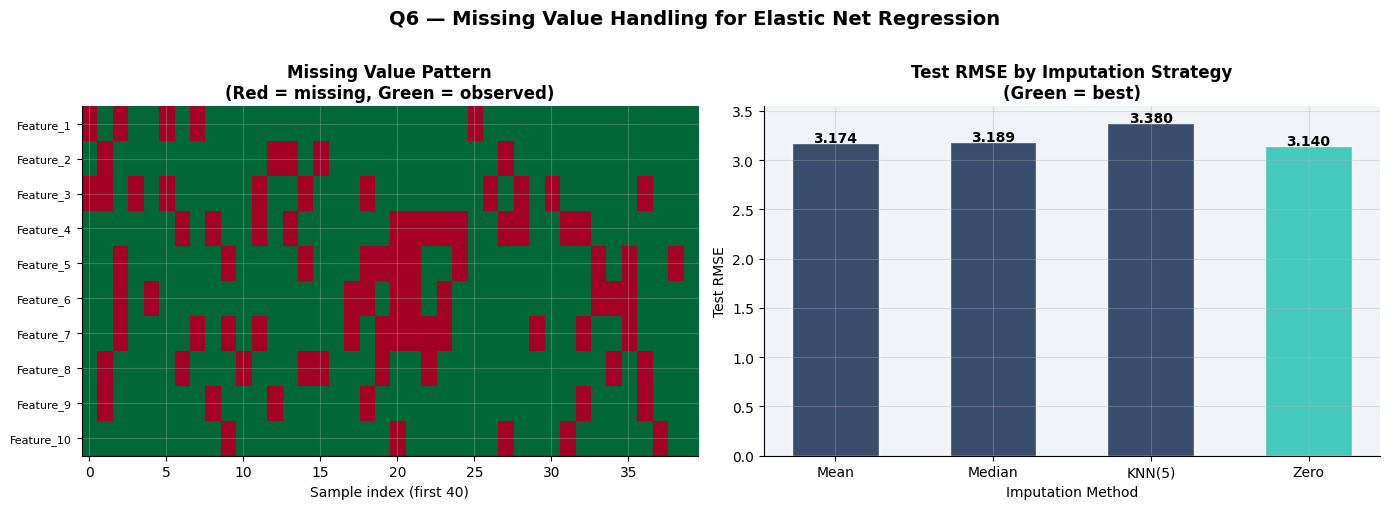

In [7]:
# ── Q6: Missing value handling strategies with Elastic Net ───────────────────
np.random.seed(42)
n6, p6 = 300, 10
feat_names6 = [f'Feature_{i+1}' for i in range(p6)]

# Create clean dataset
X6_clean = np.random.randn(n6, p6)
true6 = np.array([3,-2,1.5,0,0,2,-1,0,0,0.8])
y6 = X6_clean @ true6 + np.random.randn(n6)*2

# Introduce ~20% missing values randomly
X6_missing = X6_clean.copy().astype(float)
miss_mask = np.random.rand(n6, p6) < 0.20
X6_missing[miss_mask] = np.nan

miss_pct = miss_mask.mean(axis=0)*100
print('Missing value % per feature:')
for fname, pct in zip(feat_names6, miss_pct):
    bar = '█'*int(pct/2)
    print(f'  {fname}: {pct:5.1f}%  {bar}')

X6_tr, X6_te, y6_tr, y6_te = train_test_split(X6_missing, y6, test_size=0.25, random_state=0)

imputers = {
    'Mean'   : SimpleImputer(strategy='mean'),
    'Median' : SimpleImputer(strategy='median'),
    'KNN(5)' : KNNImputer(n_neighbors=5),
    'Zero'   : SimpleImputer(strategy='constant', fill_value=0),
}

results6 = {}
for imp_name, imputer in imputers.items():
    pipe6 = Pipeline([
        ('imputer', imputer),
        ('scaler',  StandardScaler()),
        ('model',   ElasticNetCV(l1_ratio=[0.3,0.5,0.7,0.9],
                                  cv=5, max_iter=20000))
    ])
    pipe6.fit(X6_tr, y6_tr)
    yp6 = pipe6.predict(X6_te)
    results6[imp_name] = {
        'RMSE'    : np.sqrt(mean_squared_error(y6_te, yp6)),
        'R²'      : r2_score(y6_te, yp6),
        'Best α'  : pipe6.named_steps['model'].alpha_,
        'Best ρ'  : pipe6.named_steps['model'].l1_ratio_,
    }

# Baseline: complete cases only
complete_rows = ~np.isnan(X6_tr).any(axis=1)
if complete_rows.sum() > 20:
    sc6_cc = StandardScaler()
    X6_tr_cc = sc6_cc.fit_transform(X6_tr[complete_rows])
    X6_te_cc = sc6_cc.transform(X6_te[~np.isnan(X6_te).any(axis=1)])
    y6_tr_cc = y6_tr[complete_rows]
    y6_te_cc = y6_te[~np.isnan(X6_te).any(axis=1)]
    cc_m = ElasticNetCV(cv=5,max_iter=20000).fit(X6_tr_cc, y6_tr_cc)
    yp_cc = cc_m.predict(X6_te_cc)
    results6['Drop rows'] = {
        'RMSE': np.sqrt(mean_squared_error(y6_te_cc,yp_cc)),
        'R²'  : r2_score(y6_te_cc,yp_cc),
        'Best α': cc_m.alpha_, 'Best ρ': cc_m.l1_ratio_
    }

print('\nImputation Strategy Comparison')
print('='*58)
print(pd.DataFrame(results6).T.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing pattern heatmap
sample_miss = X6_missing[:40]
is_nan = np.isnan(sample_miss).astype(float)
axes[0].imshow(is_nan.T, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_xlabel('Sample index (first 40)')
axes[0].set_yticks(range(p6))
axes[0].set_yticklabels(feat_names6, fontsize=8)
axes[0].set_title('Missing Value Pattern\n(Red = missing, Green = observed)',
                   fontsize=12, fontweight='bold')

# RMSE comparison
strats = list(results6.keys())
rmses6 = [results6[s]['RMSE'] for s in strats]
bar_c6 = [C4 if r==min(rmses6) else C2 for r in rmses6]
bars6 = axes[1].bar(strats, rmses6, color=bar_c6, alpha=0.87, edgecolor='white', width=0.55)
for bar, v in zip(bars6, rmses6):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}',
                 ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Test RMSE by Imputation Strategy\n(Green = best)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Test RMSE')
axes[1].set_xlabel('Imputation Method')

plt.suptitle('Q6 — Missing Value Handling for Elastic Net Regression',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q7 — How do you use Elastic Net Regression for feature selection?


### 📖 Theory

Elastic Net performs **automatic feature selection** through its L1 component, which forces
some coefficients to exactly zero.

#### Feature selection workflow

```
Raw Data → Standardise → ElasticNetCV → Extract non-zero coefs → Selected features → Final model
```

#### Selection methods with Elastic Net

| Method | How | Notes |
|--------|-----|-------|
| **Direct zeroing** | Coefs where β = 0 are excluded | Main mechanism via L1 |
| **Threshold** | Keep features where \|β\| > ε | More aggressive selection |
| **SelectFromModel** | sklearn wrapper around non-zero coefs | Clean pipeline integration |
| **Stability selection** | Run EN on many bootstrap samples | Robust to sample variation |

> 💡 The `l1_ratio` controls how many features are excluded:
> - Higher ρ → more zeros → fewer selected features
> - Lower ρ → fewer zeros → more features retained


  Elastic Net Feature Selection Results
  Optimal α : 0.12626 | Optimal ρ : 1.00
  Features selected (non-zero) : 23 / 30
  True informative features    : 8 / 30
  True positives  : 8 | False positives: 15 | False negatives: 0

  Full EN model RMSE : 2.6750
  OLS on selected    : 2.9468


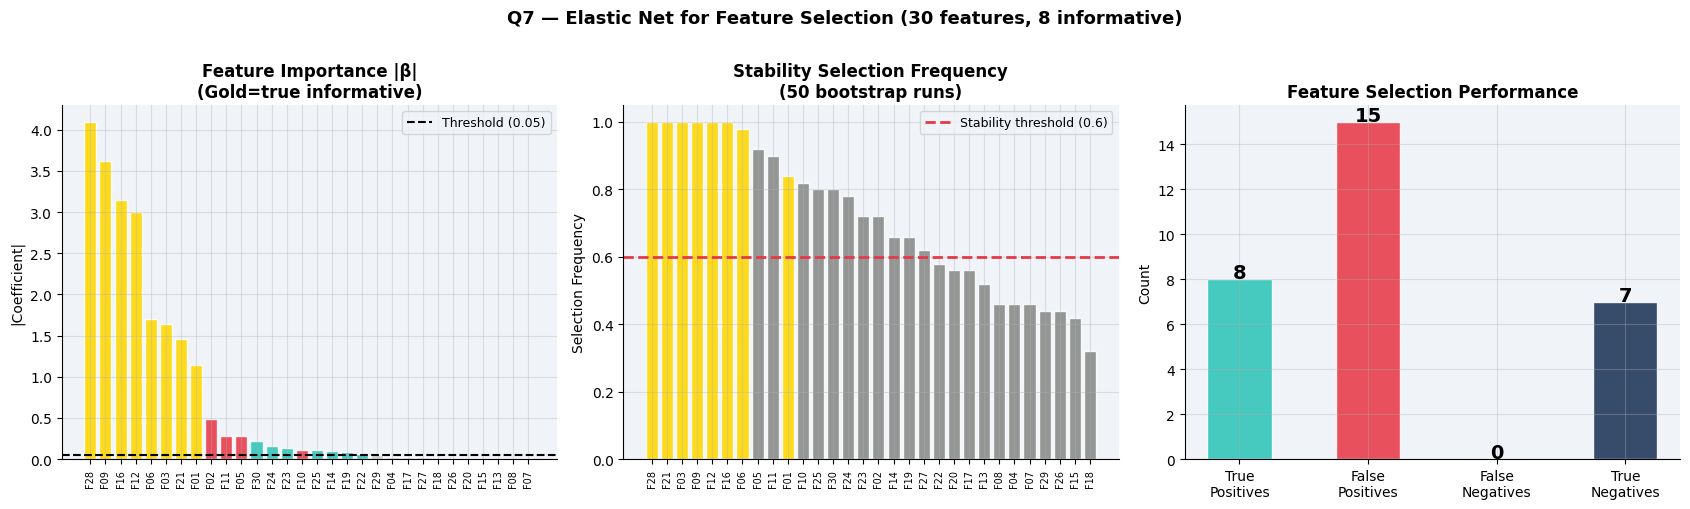

In [8]:
# ── Q7: Elastic Net feature selection — full workflow ─────────────────────────
from sklearn.feature_selection import SelectFromModel

np.random.seed(42)
n7, p7 = 250, 30
n_informative7 = 8

# 8 truly informative, 22 noise features
info_idx = [0,2,5,8,11,15,20,27]
true7 = np.zeros(p7)
true7[info_idx] = np.random.choice([-1,1],n_informative7)*np.random.uniform(1.5,4,n_informative7)
feat_names7 = [f'F{i+1:02d}' for i in range(p7)]

X7 = np.random.randn(n7, p7)
# Add correlated features
X7[:,1]  = X7[:,0]  + np.random.randn(n7)*0.15
X7[:,6]  = X7[:,5]  + np.random.randn(n7)*0.20
y7 = X7 @ true7 + np.random.randn(n7)*2.5

X7_tr, X7_te, y7_tr, y7_te = train_test_split(X7, y7, test_size=0.25, random_state=3)
sc7 = StandardScaler()
X7_tr_s = sc7.fit_transform(X7_tr)
X7_te_s = sc7.transform(X7_te)

# ── Step 1: Fit ElasticNetCV ──────────────────────────────────────────────────
en7 = ElasticNetCV(l1_ratio=[0.3,0.5,0.7,0.9,1.0],
                   alphas=np.logspace(-4,1,80),
                   cv=5, max_iter=20000, random_state=0)
en7.fit(X7_tr_s, y7_tr)

# ── Step 2: SelectFromModel ───────────────────────────────────────────────────
selector7 = SelectFromModel(en7, prefit=True)
selected_mask7 = selector7.get_support()
selected_feats7 = np.array(feat_names7)[selected_mask7]

# ── Step 3: Stability selection (50 bootstrap runs) ──────────────────────────
selection_freq = np.zeros(p7)
for _ in range(50):
    idx_boot = np.random.choice(len(X7_tr_s), len(X7_tr_s), replace=True)
    m_boot = ElasticNet(alpha=en7.alpha_, l1_ratio=en7.l1_ratio_,
                         max_iter=10000).fit(X7_tr_s[idx_boot], y7_tr[idx_boot])
    selection_freq += (np.abs(m_boot.coef_) > 1e-4).astype(float)
selection_freq /= 50  # fraction of times selected

print('='*60)
print('  Elastic Net Feature Selection Results')
print('='*60)
print(f'  Optimal α : {en7.alpha_:.5f} | Optimal ρ : {en7.l1_ratio_:.2f}')
print(f'  Features selected (non-zero) : {selected_mask7.sum()} / {p7}')
print(f'  True informative features    : {n_informative7} / {p7}')

true_positives  = np.sum(selected_mask7 & (np.abs(true7)>0))
false_positives = np.sum(selected_mask7 & (np.abs(true7)==0))
false_negatives = np.sum(~selected_mask7 & (np.abs(true7)>0))
print(f'  True positives  : {true_positives} | False positives: {false_positives} | False negatives: {false_negatives}')

# Retrain on selected features only
X7_tr_sel = X7_tr_s[:, selected_mask7]
X7_te_sel = X7_te_s[:, selected_mask7]
final7 = LinearRegression().fit(X7_tr_sel, y7_tr)
yp7_all = en7.predict(X7_te_s)
yp7_sel = final7.predict(X7_te_sel)
print(f'\n  Full EN model RMSE : {np.sqrt(mean_squared_error(y7_te,yp7_all)):.4f}')
print(f'  OLS on selected    : {np.sqrt(mean_squared_error(y7_te,yp7_sel)):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Coefficient plot — sorted
sorted_i7 = np.argsort(np.abs(en7.coef_))[::-1]
bar_c7 = ['gold' if i in info_idx else (C4 if en7.coef_[i]>0.05 else
            (C1 if en7.coef_[i]<-0.05 else '#CCCCCC')) for i in sorted_i7]
axes[0].bar(range(p7), np.abs(en7.coef_[sorted_i7]),
             color=bar_c7, alpha=0.88, edgecolor='white')
axes[0].axhline(0.05, color='black', ls='--', lw=1.5, label='Threshold (0.05)')
axes[0].set_xticks(range(p7))
axes[0].set_xticklabels(np.array(feat_names7)[sorted_i7], rotation=90, fontsize=7)
axes[0].set_title('Feature Importance |β|\n(Gold=true informative)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('|Coefficient|'); axes[0].legend(fontsize=9)

# Stability selection
stable_sorted = np.argsort(selection_freq)[::-1]
stable_colors = ['gold' if i in info_idx else ('#888888') for i in stable_sorted]
axes[1].bar(range(p7), selection_freq[stable_sorted],
             color=stable_colors, alpha=0.88, edgecolor='white')
axes[1].axhline(0.6, color=C1, ls='--', lw=2, label='Stability threshold (0.6)')
axes[1].set_xticks(range(p7))
axes[1].set_xticklabels(np.array(feat_names7)[stable_sorted], rotation=90, fontsize=7)
axes[1].set_title('Stability Selection Frequency\n(50 bootstrap runs)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Selection Frequency'); axes[1].legend(fontsize=9)

# Selection results summary
categories = ['True\nPositives', 'False\nPositives', 'False\nNegatives', 'True\nNegatives']
values7 = [true_positives, false_positives, false_negatives,
            p7-true_positives-false_positives-false_negatives]
bar_colors7 = [C4, C1, C5, C2]
bars7 = axes[2].bar(categories, values7, color=bar_colors7, alpha=0.88, edgecolor='white', width=0.5)
for bar, v in zip(bars7, values7):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.05, str(v),
                 ha='center', fontweight='bold', fontsize=14)
axes[2].set_title('Feature Selection Performance', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('Q7 — Elastic Net for Feature Selection (30 features, 8 informative)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q8 — How do you pickle and unpickle a trained Elastic Net model in Python?


### 📖 Theory

**Pickling** serialises a Python object to a byte stream so it can be saved to disk and
reloaded later without retraining.

#### Two main tools

| Tool | Module | Best for |
|------|--------|----------|
| `pickle` | Built-in Python | General Python objects, small models |
| `joblib` | `sklearn.externals` / `joblib` | **Recommended for sklearn models** — handles large numpy arrays efficiently |

#### Workflow
```
Train → pickle.dump() → .pkl file on disk
                              ↓
New session → pickle.load() → restored model → predict(X_new)
```

#### Important: save the scaler too!
```python
# Save
joblib.dump({'model': en, 'scaler': sc}, 'elastic_net_bundle.pkl')
# Load
bundle = joblib.load('elastic_net_bundle.pkl')
en_loaded = bundle['model']
sc_loaded  = bundle['scaler']
```


Model trained.  Test RMSE = 9.9817
Best α=0.10081, ρ=0.90

[pickle] Saved  → elastic_net_model.pkl  (20.3 KB, 0.9 ms)
[pickle] Loaded ← elastic_net_model.pkl  (0.3 ms)
         Test RMSE after reload = 9.9817  ✅ Identical: True

[joblib] Saved  → elastic_net_model.joblib  (19.2 KB, 2.0 ms)
[joblib] Loaded ← elastic_net_model.joblib  (1.0 ms)
         Test RMSE after reload = 9.9817  ✅ Identical: True

Saved metadata: {'alpha': np.float64(0.10080838884650782), 'l1_ratio': np.float64(0.9), 'trained_on': 'make_regression n=300 p=15'}


AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

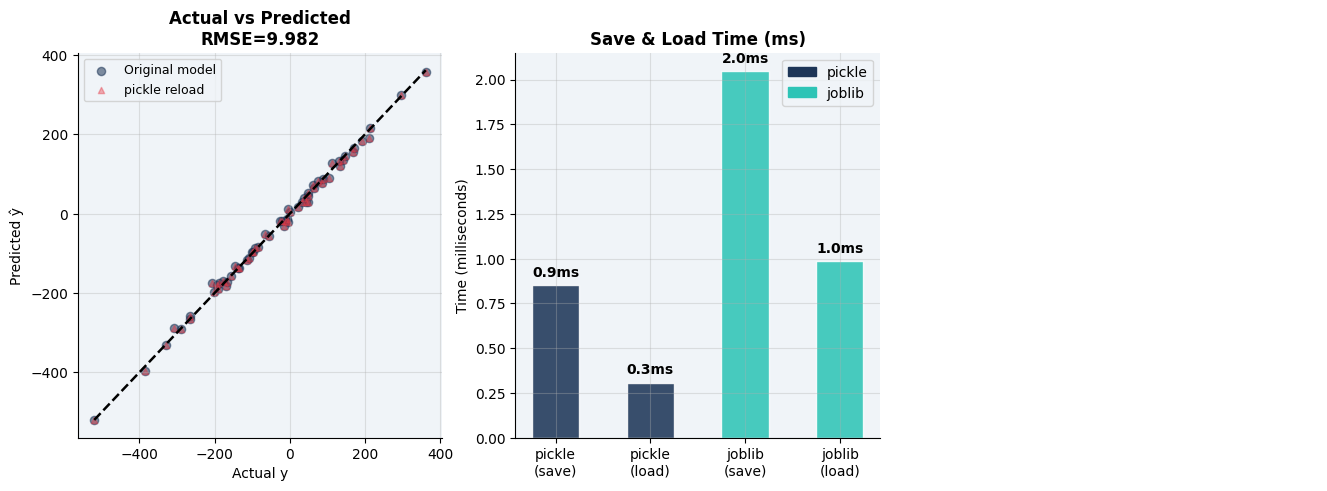

In [9]:
# ── Q8: Pickle and unpickle Elastic Net — complete demonstration ──────────────
import pickle, joblib, os, time

# ── Build and train a model ───────────────────────────────────────────────────
np.random.seed(42)
X8, y8, _ = make_regression(n_samples=300, n_features=15,
                              n_informative=8, noise=10,
                              coef=True, random_state=42)
X8_tr, X8_te, y8_tr, y8_te = train_test_split(X8, y8, test_size=0.2, random_state=0)
sc8 = StandardScaler()
X8_tr_s = sc8.fit_transform(X8_tr)
X8_te_s = sc8.transform(X8_te)

en8 = ElasticNetCV(l1_ratio=[0.3,0.5,0.7,0.9], cv=5, max_iter=20000).fit(X8_tr_s, y8_tr)
yp_before = en8.predict(X8_te_s)
rmse_before = np.sqrt(mean_squared_error(y8_te, yp_before))
print(f'Model trained.  Test RMSE = {rmse_before:.4f}')
print(f'Best α={en8.alpha_:.5f}, ρ={en8.l1_ratio_:.2f}')

# ──────────────────────────────────────────────────────────────────────────────
# METHOD 1: pickle (built-in)
# ──────────────────────────────────────────────────────────────────────────────
pkl_path = 'elastic_net_model.pkl'
bundle8  = {'model': en8, 'scaler': sc8,
             'metadata': {'alpha': en8.alpha_, 'l1_ratio': en8.l1_ratio_,
                          'trained_on': 'make_regression n=300 p=15'}}

t0 = time.time()
with open(pkl_path, 'wb') as f:
    pickle.dump(bundle8, f)
t_save_pickle = time.time()-t0

size_pickle = os.path.getsize(pkl_path)/1024
print(f'\n[pickle] Saved  → {pkl_path}  ({size_pickle:.1f} KB, {t_save_pickle*1000:.1f} ms)')

t0 = time.time()
with open(pkl_path, 'rb') as f:
    bundle_loaded_pkl = pickle.load(f)
t_load_pickle = time.time()-t0

en8_pkl  = bundle_loaded_pkl['model']
sc8_pkl  = bundle_loaded_pkl['scaler']
yp_pkl   = en8_pkl.predict(sc8_pkl.transform(X8_te))
rmse_pkl = np.sqrt(mean_squared_error(y8_te, yp_pkl))
print(f'[pickle] Loaded ← {pkl_path}  ({t_load_pickle*1000:.1f} ms)')
print(f'         Test RMSE after reload = {rmse_pkl:.4f}  ✅ Identical: {np.isclose(rmse_before,rmse_pkl)}')

# ──────────────────────────────────────────────────────────────────────────────
# METHOD 2: joblib (recommended for sklearn)
# ──────────────────────────────────────────────────────────────────────────────
jbl_path = 'elastic_net_model.joblib'

t0 = time.time()
joblib.dump(bundle8, jbl_path, compress=3)
t_save_jbl = time.time()-t0
size_jbl = os.path.getsize(jbl_path)/1024

print(f'\n[joblib] Saved  → {jbl_path}  ({size_jbl:.1f} KB, {t_save_jbl*1000:.1f} ms)')

t0 = time.time()
bundle_loaded_jbl = joblib.load(jbl_path)
t_load_jbl = time.time()-t0

en8_jbl  = bundle_loaded_jbl['model']
sc8_jbl  = bundle_loaded_jbl['scaler']
yp_jbl   = en8_jbl.predict(sc8_jbl.transform(X8_te))
rmse_jbl = np.sqrt(mean_squared_error(y8_te, yp_jbl))
print(f'[joblib] Loaded ← {jbl_path}  ({t_load_jbl*1000:.1f} ms)')
print(f'         Test RMSE after reload = {rmse_jbl:.4f}  ✅ Identical: {np.isclose(rmse_before,rmse_jbl)}')
print(f'\nSaved metadata: {bundle_loaded_jbl["metadata"]}')

# ──────────────────────────────────────────────────────────────────────────────
# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted (original)
mn8, mx8 = y8_te.min(), y8_te.max()
axes[0].scatter(y8_te, yp_before, alpha=0.55, color=C2, s=35, label='Original model')
axes[0].scatter(y8_te, yp_pkl,    alpha=0.40, color=C1, s=20, marker='^', label='pickle reload')
axes[0].plot([mn8,mx8],[mn8,mx8],'--',color='black',lw=1.8)
axes[0].set_title(f'Actual vs Predicted\nRMSE={rmse_before:.3f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual y'); axes[0].set_ylabel('Predicted ŷ'); axes[0].legend(fontsize=9)

# File size & timing comparison
methods = ['pickle\n(save)','pickle\n(load)','joblib\n(save)','joblib\n(load)']
times_ms = [t_save_pickle*1000, t_load_pickle*1000, t_save_jbl*1000, t_load_jbl*1000]
bar_c8 = [C2,C2,C4,C4]
bars8 = axes[1].bar(methods, times_ms, color=bar_c8, alpha=0.87, edgecolor='white', width=0.5)
for bar, v in zip(bars8, times_ms):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.1f}ms',
                 ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Save & Load Time (ms)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Time (milliseconds)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=C2,label='pickle'),Patch(color=C4,label='joblib')], fontsize=10)

# Pickling workflow diagram
axes[2].axis('off')
workflow = [
    ('① Train Model',    '#1D3557', 'white'),
    ('② pickle.dump()',  '#457B9D', 'white'),
    ('③ .pkl on Disk',  '#2EC4B6', '#0d1b2a'),
    ('④ pickle.load()', '#457B9D', 'white'),
    ('⑤ Predict(X_new)', '#E63946', 'white'),
]
for i, (step, fc, tc) in enumerate(workflow):
    y_pos = 0.88 - i*0.18
    axes[2].add_patch(plt.FancyBboxPatch((0.05, y_pos-0.06), 0.9, 0.12,
                       boxstyle='round,pad=0.02', facecolor=fc, edgecolor='white', lw=2))
    axes[2].text(0.50, y_pos, step, ha='center', va='center',
                 fontsize=12, color=tc, fontweight='bold')
    if i < len(workflow)-1:
        axes[2].annotate('', xy=(0.50, y_pos-0.07), xytext=(0.50, y_pos-0.06),
                          arrowprops=dict(arrowstyle='->', color='grey', lw=1.5))
axes[2].set_xlim(0,1); axes[2].set_ylim(0,1)
axes[2].set_title('Pickling Workflow', fontsize=12, fontweight='bold')

plt.suptitle('Q8 — Pickle & Unpickle Elastic Net (pickle + joblib)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cleanup
os.remove(pkl_path); os.remove(jbl_path)
print('\n🧹 Temp files removed.')


---
## Q9 — What is the purpose of pickling a model in machine learning?


### 📖 Theory

**Pickling** (model serialisation) is the process of converting a trained ML model into a
byte stream that can be stored on disk and reloaded later.

#### Why pickle a model?

| Purpose | Detail |
|---------|--------|
| 🚀 **Deployment** | Serve predictions in a web API (Flask, FastAPI) without retraining |
| ⏱️ **Save training time** | Training can take hours/days — pickle once, load instantly |
| 🔄 **Reproducibility** | Exact same model parameters used across experiments |
| 🔀 **Sharing** | Send trained model to colleagues or clients |
| 🗂️ **Versioning** | Archive model versions alongside datasets |
| 🔁 **Batch scoring** | Load model in offline batch jobs to score new data |
| 🧪 **A/B testing** | Load and compare multiple pickled model versions in production |

#### Best practices

| ✅ Do | ❌ Don't |
|-------|----------|
| Save scaler + model together | Forget to save the scaler |
| Use `joblib` for sklearn models | Use pickle for very large numpy arrays |
| Version your pickle files | Overwrite without versioning |
| Check sklearn version on load | Load on mismatched sklearn version |
| Document training data/params | Lose track of what the model was trained on |


💾  Model saved: elastic_net_v1.joblib  (19.2 KB)
    Metadata: {
      "model_type": "ElasticNetCV",
      "alpha": 0.10362671573929287,
      "l1_ratio": 0.9,
      "n_features": 12,
      "train_samples": 320,
      "test_rmse": 8.333986922525904,
      "test_r2": 0.9965299259661378,
      "trained_at": "2026-05-08 08:12:08",
      "sklearn_ver": "1.x",
      "version": "v1.0.0"
}

📦  Simulating production inference...

  Model version   : v1.0.0
  Trained at      : 2026-05-08 08:12:08
  α=0.10363, ρ=0.90
  Training RMSE   : 8.3340

  Predictions on 5 new samples:
    Sample 1: ŷ = 92.3854
    Sample 2: ŷ = -196.5691
    Sample 3: ŷ = 102.2460
    Sample 4: ŷ = 153.0491
    Sample 5: ŷ = 219.1375


AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

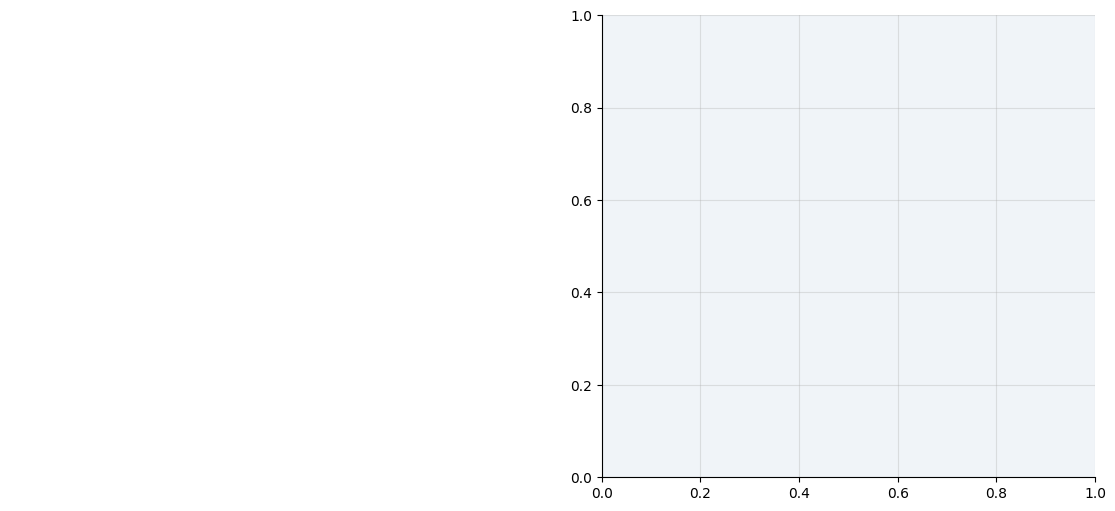

In [10]:
# ── Q9: Production pickling — best practices demo ────────────────────────────
import pickle, joblib, os, json
from datetime import datetime

# ── Train final model ─────────────────────────────────────────────────────────
np.random.seed(42)
X9, y9, _ = make_regression(n_samples=400, n_features=12, n_informative=7,
                              noise=8, coef=True, random_state=42)
X9_tr, X9_te, y9_tr, y9_te = train_test_split(X9, y9, test_size=0.2, random_state=0)
sc9 = StandardScaler()
X9_tr_s = sc9.fit_transform(X9_tr)
X9_te_s = sc9.transform(X9_te)

en9 = ElasticNetCV(l1_ratio=[0.3,0.5,0.7,0.9], cv=5, max_iter=20000).fit(X9_tr_s, y9_tr)
yp9 = en9.predict(X9_te_s)
rmse9 = np.sqrt(mean_squared_error(y9_te, yp9))

# ── Production-quality bundle ─────────────────────────────────────────────────
model_bundle = {
    'model'     : en9,
    'scaler'    : sc9,
    'metadata'  : {
        'model_type'    : 'ElasticNetCV',
        'alpha'         : float(en9.alpha_),
        'l1_ratio'      : float(en9.l1_ratio_),
        'n_features'    : X9_tr.shape[1],
        'train_samples' : X9_tr.shape[0],
        'test_rmse'     : float(rmse9),
        'test_r2'       : float(r2_score(y9_te, yp9)),
        'trained_at'    : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'sklearn_ver'   : '1.x',
        'version'       : 'v1.0.0',
    }
}

# ── Save with joblib ──────────────────────────────────────────────────────────
model_path = 'elastic_net_v1.joblib'
joblib.dump(model_bundle, model_path, compress=3)
print(f'💾  Model saved: {model_path}  ({os.path.getsize(model_path)/1024:.1f} KB)')
print(f'    Metadata: {json.dumps(model_bundle["metadata"], indent=6)}')

# ── Simulate production: new data arrives ─────────────────────────────────────
print('\n📦  Simulating production inference...')
loaded_bundle = joblib.load(model_path)
loaded_model  = loaded_bundle['model']
loaded_scaler = loaded_bundle['scaler']
loaded_meta   = loaded_bundle['metadata']

X_new = np.random.randn(5, 12)   # 5 new samples
X_new_scaled = loaded_scaler.transform(X_new)
y_new_pred   = loaded_model.predict(X_new_scaled)

print(f'\n  Model version   : {loaded_meta["version"]}')
print(f'  Trained at      : {loaded_meta["trained_at"]}')
print(f'  α={loaded_meta["alpha"]:.5f}, ρ={loaded_meta["l1_ratio"]:.2f}')
print(f'  Training RMSE   : {loaded_meta["test_rmse"]:.4f}')
print(f'\n  Predictions on 5 new samples:')
for i, pred in enumerate(y_new_pred):
    print(f'    Sample {i+1}: ŷ = {pred:.4f}')

# ── Visualise pickling purposes ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Purposes diagram
axes[0].axis('off')
purposes = [
    ('🚀 Deployment',      'Serve predictions\nvia Flask/FastAPI',  C2),
    ('⏱ Save Train Time', 'Load in ms,\nnot hours',                C3),
    ('🔄 Reproducibility', 'Exact same model\nacross experiments',  C4),
    ('🔀 Sharing',         'Send model to\ncolleagues/clients',      C5),
    ('🗂 Versioning',      'Archive models\nwith datasets',          C1),
    ('🔁 Batch Scoring',   'Score new data\nwithout retraining',    C6),
]
for i, (title, detail, color) in enumerate(purposes):
    row, col_n = divmod(i, 2)
    x, y_p = col_n*0.52+0.02, 0.92-row*0.32
    axes[0].add_patch(plt.FancyBboxPatch((x, y_p-0.20), 0.46, 0.25,
                       boxstyle='round,pad=0.02', facecolor=color,
                       edgecolor='white', lw=2, alpha=0.85))
    axes[0].text(x+0.23, y_p-0.06, title,  ha='center', va='center',
                 fontsize=10.5, color='white', fontweight='bold')
    axes[0].text(x+0.23, y_p-0.14, detail, ha='center', va='center',
                 fontsize=8.5, color='white')
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
axes[0].set_title('Why Pickle? — 6 Key Purposes', fontsize=13, fontweight='bold')

# Actual vs predicted for loaded model
mn9, mx9 = y9_te.min(), y9_te.max()
axes[1].scatter(y9_te, yp9, alpha=0.55, color=C2, s=35, label='Predictions')
axes[1].plot([mn9,mx9],[mn9,mx9],'--', color=C1, lw=2, label='Perfect fit')
axes[1].set_xlabel('Actual y'); axes[1].set_ylabel('Predicted ŷ')
axes[1].set_title(f'Loaded Model Performance\nRMSE={rmse9:.3f}  R²={r2_score(y9_te,yp9):.3f}',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Q9 — Purpose of Pickling in Machine Learning',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

os.remove(model_path)
print('\n🧹  Temp file removed. All done!')
